### Threshold theories
**Cell 1 = Version 1** (the threshold varies). **Cell 2 = Version 2** (the signal varies). Run both, edit the `👈` values, and notice how similar the two versions look.

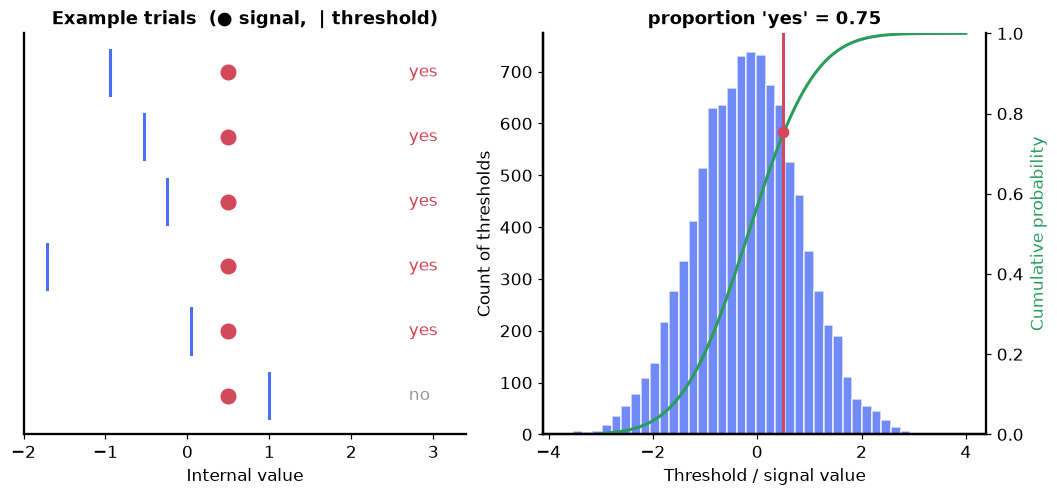

In [1]:
# (hide matplotlib's harmless one-time "building the font cache" message)
import logging; logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

plt.rcParams.update({
    "figure.dpi": 110, "font.size": 11, "axes.titlesize": 12,
    "axes.titleweight": "semibold", "axes.linewidth": 1.5,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": False, "legend.frameon": False,
})
NOISE  = "#4c6ef5"   # the threshold
SIGNAL = "#d1495b"   # the signal
CUMUL  = "#2a9d5c"   # cumulative curve

# Version 1: the THRESHOLD varies from trial to trial (the signal is fixed)
signal_strength = 0.5       # 👈 fixed signal strength
threshold_mean  = -0.1745   # chosen so that proportion 'yes' = 0.75
threshold_sd    = 1         # 👈 how variable the threshold is
n_examples      = 6
ntrials         = 10000
rng = np.random.default_rng()

fig, (axL, axR) = plt.subplots(1, 2, figsize=(9.5, 4.4), constrained_layout=True)

# left: a few example trials  (● = signal, | = the trial's threshold)
for t in range(n_examples):
    thr = rng.normal(threshold_mean, threshold_sd)
    axL.plot([thr, thr], [t - 0.35, t + 0.35], color=NOISE, lw=2)
    axL.scatter(signal_strength, t, 90, color=SIGNAL, zorder=3)
    yes = signal_strength > thr
    axL.text(2.7, t, "yes" if yes else "no", va="center",
             color=SIGNAL if yes else "0.6")
axL.set(xlim=(-2, 3.4), ylim=(-0.6, n_examples - 0.4), yticks=[],
        xlabel="Internal value", title="Example trials  (● signal,  | threshold)")

# right: over many trials, proportion 'yes' = how often the threshold falls below the signal
thresholds = rng.normal(threshold_mean, threshold_sd, ntrials)
proportion_yes = np.mean(thresholds <= signal_strength)
axR.hist(thresholds, bins=40, color=NOISE, alpha=0.8, edgecolor="white")
axR.axvline(signal_strength, color=SIGNAL, lw=2)
axR.set(xlabel="Threshold / signal value", ylabel="Count of thresholds",
        title=f"proportion 'yes' = {proportion_yes:.2g}")
axR2 = axR.twinx(); axR2.spines["right"].set_visible(True)
xs = np.linspace(-3, 4, 300)
axR2.plot(xs, norm.cdf(xs, threshold_mean, threshold_sd), color=CUMUL, lw=2)
axR2.scatter([signal_strength], [proportion_yes], 45, color=SIGNAL, zorder=4)
axR2.set_ylabel("Cumulative probability", color=CUMUL); axR2.set_ylim(0, 1)
plt.show()


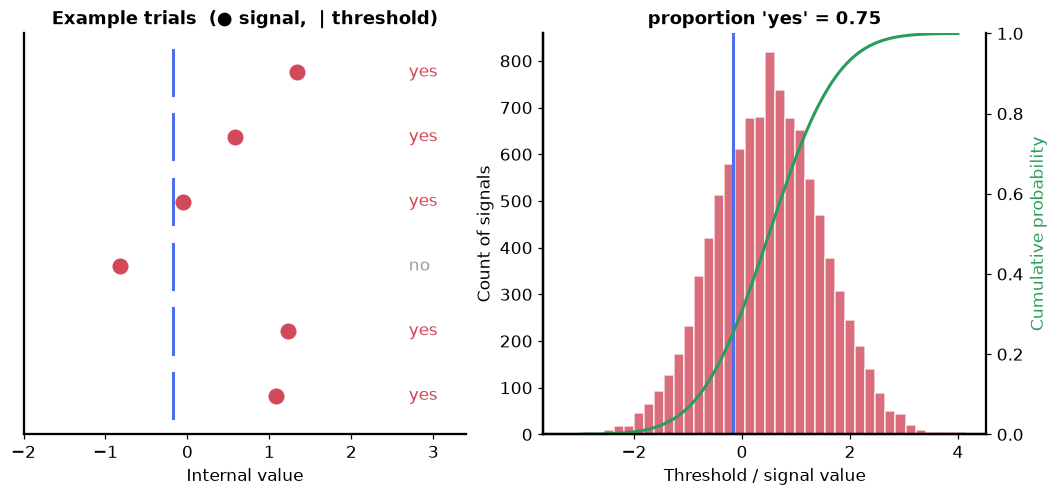

In [2]:
# (hide matplotlib's harmless one-time "building the font cache" message)
import logging; logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

plt.rcParams.update({
    "figure.dpi": 110, "font.size": 11, "axes.titlesize": 12,
    "axes.titleweight": "semibold", "axes.linewidth": 1.5,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": False, "legend.frameon": False,
})
NOISE  = "#4c6ef5"   # the threshold
SIGNAL = "#d1495b"   # the signal
CUMUL  = "#2a9d5c"   # cumulative curve

# Version 2: the SIGNAL varies from trial to trial (the threshold is fixed)
# Warning: this looks very similar to Version 1 — watch what is fixed vs variable!
threshold   = -0.1745   # 👈 fixed threshold
signal_mean = 0.5       # 👈 average signal strength
signal_sd   = 1         # how variable the signal is
n_examples  = 6
ntrials     = 10000
rng = np.random.default_rng()

fig, (axL, axR) = plt.subplots(1, 2, figsize=(9.5, 4.4), constrained_layout=True)

# left: a few example trials  (● = that trial's signal, | = the fixed threshold)
for t in range(n_examples):
    sig = rng.normal(signal_mean, signal_sd)
    axL.plot([threshold, threshold], [t - 0.35, t + 0.35], color=NOISE, lw=2)
    axL.scatter(sig, t, 90, color=SIGNAL, zorder=3)
    yes = sig > threshold
    axL.text(2.7, t, "yes" if yes else "no", va="center",
             color=SIGNAL if yes else "0.6")
axL.set(xlim=(-2, 3.4), ylim=(-0.6, n_examples - 0.4), yticks=[],
        xlabel="Internal value", title="Example trials  (● signal,  | threshold)")

# right: over many trials, proportion 'yes' = how often the signal exceeds the threshold
signals = rng.normal(signal_mean, signal_sd, ntrials)
proportion_yes = np.mean(signals > threshold)
axR.hist(signals, bins=40, color=SIGNAL, alpha=0.8, edgecolor="white")
axR.axvline(threshold, color=NOISE, lw=2)
axR.set(xlabel="Threshold / signal value", ylabel="Count of signals",
        title=f"proportion 'yes' = {proportion_yes:.2g}")
axR2 = axR.twinx(); axR2.spines["right"].set_visible(True)
xs = np.linspace(-3, 4, 300)
axR2.plot(xs, norm.cdf(xs, signal_mean, signal_sd), color=CUMUL, lw=2)
axR2.set_ylabel("Cumulative probability", color=CUMUL); axR2.set_ylim(0, 1)
plt.show()
